In [4]:
import json
import re

with open("de_eda.ipynb", "r", encoding="utf-8") as f:
    notebook = json.load(f)

old_text = "Math-3 Theory"
new_text = "sdfsd#@###3DDDfsa"
pattern = re.compile(re.escape(old_text), re.IGNORECASE)

for cell in notebook["cells"]:
    if cell["cell_type"] in ("code", "markdown"):
        cell["source"] = [pattern.sub(new_text, line) for line in cell["source"]]

with open("de_eda.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)


In [5]:
import json
import re

with open("de_eda.ipynb", "r", encoding="utf-8") as f:
    notebook = json.load(f)

old_text = "DE Theory"
new_text = "Math-3 Theory"
pattern = re.compile(re.escape(old_text), re.IGNORECASE)

for cell in notebook["cells"]:
    if cell["cell_type"] in ("code", "markdown"):
        cell["source"] = [pattern.sub(new_text, line) for line in cell["source"]]

with open("de_eda.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)


In [6]:
import json
import re

with open("de_eda.ipynb", "r", encoding="utf-8") as f:
    notebook = json.load(f)

old_text = "sdfsd#@###3DDDfsa"
new_text = "DE Theory"
pattern = re.compile(re.escape(old_text), re.IGNORECASE)

for cell in notebook["cells"]:
    if cell["cell_type"] in ("code", "markdown"):
        cell["source"] = [pattern.sub(new_text, line) for line in cell["source"]]

with open("de_eda.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Read the math train data
df = pd.read_csv("../train_dataset.csv")

# Drop the irrelevant, data leak columns
df = df.drop(
    columns=[
        "Student ID",
        "Mentor-1",
        "Mentor-2",
        "Mentor-3",
        "Roll-2",
        "Roll-3",
        "Math-3 Theory",
        "DE Practical",
        "FSD Theory",
        "FSD Practical",
        "Python Theory",
        "Python Practical",
        "Communication Theory",
        "Law Theory",
    ]
)

# columns for Semester 1 core subjects
sem1_columns = [
    "Math-1 Theory",
    "Physics Theory",
    "Java-1 Theory",
    "Software Engineering Theory",
]

# Calculate Semester 1 Percentage as the average of core subject scores
df["Sem 1 Percentage"] = df[sem1_columns].mean(axis=1).round(2)

# columns for Semester 2 core subjects
sem2_columns = [
    "Math-2 Theory",
    "Data Structures using Java Theory",
    "DBMS Theory",
    "Fundamental of Electronics and Electrical Theory",
    "Java-2 Theory",
]

# Calculate Semester 2 Percentage as the average of core subject scores
df["Sem 2 Percentage"] = df[sem2_columns].mean(axis=1).round(2)


# Rename columns Div-1, Div-2, Div-3 to Section-1, Section-2, Section-3
df = df.rename(
    columns={"Div-1": "Section-1", "Div-2": "Section-2", "Div-3": "Section-3"}
)

# Transform values in Section-1, Section-2, Section-3 to keep only the first character
for section in ["Section-1", "Section-2", "Section-3"]:
    df[section] = df[section].str[0]

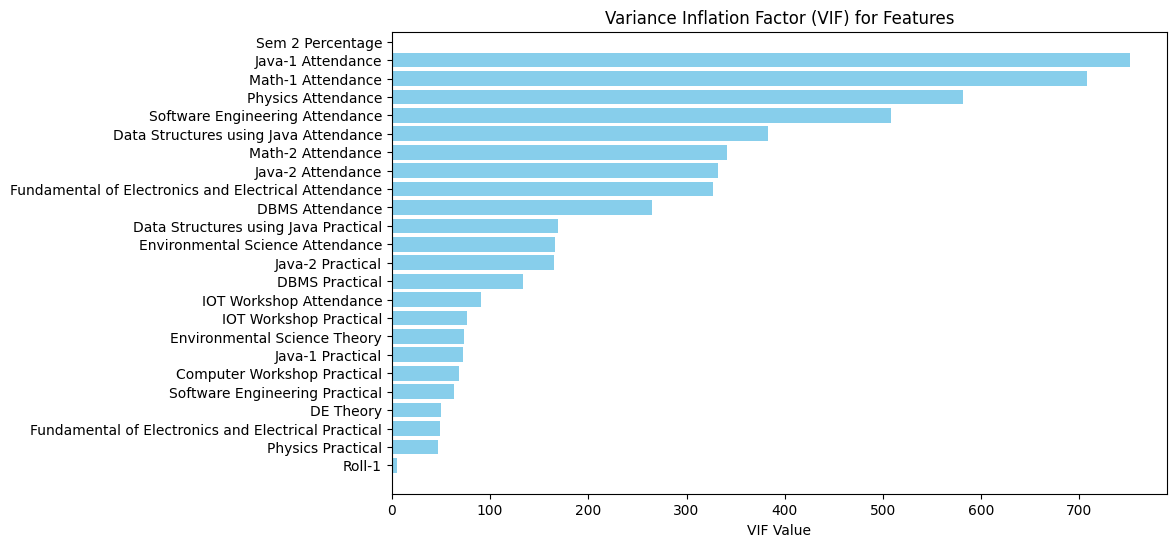

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF calculation
numeric_df = df.select_dtypes(include=["number"]).dropna()

# Calculate VIF for each column
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(numeric_df.values, i)
    for i in range(numeric_df.shape[1])
]

# Sort by VIF for clarity
vif_data = vif_data.sort_values("VIF", ascending=False)

# Plot the VIF values
plt.figure(figsize=(10, 6))
plt.barh(vif_data["Feature"], vif_data["VIF"], color="skyblue")
plt.xlabel("VIF Value")
plt.title("Variance Inflation Factor (VIF) for Features")
plt.gca().invert_yaxis()  # Highest VIF at the top
plt.show()
